# Köppel-Martin tanh-permeability no-fracture CG/PINN flux reconstruction and MRST/TPFA transport control

This notebook is the matrix-only, no-fracture counterpart of the Köppel-Martin boundary-pressure setup. It keeps the three transport flux choices used in the comparison:

- raw CG flux `v_h` from a P1 pressure solve,
- CG+PINN reconstructed flux `v_theta`,
- MRST/TPFA finite-volume flux.

The pressure problem uses `p=1` on `x=0`, `p=4` on `x=1`, homogeneous Neumann on `y=0` and `y=1`, zero source, and

\[
\kappa(x,y)=1+\frac{K_{hi}-1}{2}\left(1+\tanh\frac{x+y-1}{\delta}\right).
\]

Transport uses `S=1` on the inflow boundary at `x=1`, with outflow at `x=0` and no-flow top/bottom.


In [ ]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.io import loadmat
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False

    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

REF = 6
N_BULK = 2 ** (REF + 1)
# Raw-CG trace convention on rectangular transport/MRST faces:
#   "average"   : two-sided average on internal faces; one-sided on boundaries.
#   "geometric" : previous one-sided locate_structured_triangles() convention.
CG_INTERFACE_FLUX_MODE = "geometric"
if CG_INTERFACE_FLUX_MODE not in {"average", "geometric"}:
    raise ValueError("CG_INTERFACE_FLUX_MODE must be 'average' or 'geometric'.")
DATA_FILE = pathlib.Path("case3_ecmor/case3_mrst_export_tanh_d0p1.mat")
if not DATA_FILE.exists():
    matches = sorted(pathlib.Path.cwd().glob("**/case3_ecmor/case3_mrst_export_tanh_d0p1.mat"))
    DATA_FILE = matches[0] if matches else DATA_FILE
if not DATA_FILE.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_tanh_d0p1.mat from the notebook directory or repository root.")

mrst = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)


def _arr(key, dtype=float):
    if key not in mrst:
        raise KeyError(f"Missing MRST field {key!r}")
    return np.asarray(mrst[key], dtype=dtype)


def _meta_float(key, default=np.nan):
    if key not in mrst:
        return float(default)
    values = np.asarray(mrst[key]).reshape(-1)
    return float(values[0]) if values.size else float(default)

xc_matrix = _arr("xc_matrix", float)
p_matrix_mrst = _arr("p_matrix", float).reshape(-1)
face_neighbors = _arr("face_neighbors", np.int64)
face_flux_mrst = _arr("face_flux", float).reshape(-1)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)
face_p1 = _arr("face_p1", float)
face_p2 = _arr("face_p2", float)
face_is_boundary = _arr("face_is_boundary", bool).reshape(-1) if "face_is_boundary" in mrst else np.any(face_neighbors == 0, axis=1)
kappa_cell_mrst = _arr("kappa_cell", float).reshape(-1) if "kappa_cell" in mrst else None

nx, ny = np.asarray(mrst.get("meta_celldim", [N_BULK, N_BULK]), dtype=int).reshape(-1)
physdim = np.asarray(mrst.get("meta_physdim", [1.0, 1.0]), dtype=float).reshape(-1)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", _meta_float("meta_PV", phi_matrix * float(np.prod(physdim))))
Q_water = _meta_float("meta_Q_water", _meta_float("meta_Q_in", np.nan))
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)
KHI = _meta_float("meta_Khi", 10.0)
TANH_DELTA = _meta_float("meta_delta", 0.1)

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])
hx = physdim[0] / nx
hy = physdim[1] / ny
h_est = min(hx, hy)
ncell = int(xc_matrix.shape[0])
cell_area = np.full(ncell, float(np.prod(physdim)) / ncell, dtype=float)
cell_pv = phi_matrix * cell_area

transport_cases = []
if "sw_matrix_pvi03" in mrst:
    transport_cases.append(("PVI0.3", "sw_matrix_pvi03", "sw_matrix_pvi03_matched", _meta_float("meta_T_pvi03"), 0.3))
if "sw_matrix_pvi05" in mrst:
    transport_cases.append(("PVI0.5", "sw_matrix_pvi05", "sw_matrix_pvi05_matched", _meta_float("meta_T_pvi05"), 0.5))
if not transport_cases:
    raise KeyError("Tanh MRST export must contain sw_matrix_pvi03 and/or sw_matrix_pvi05.")

TRANSPORT_CASE_KEY = transport_cases[0][0]

print(f"Loaded {DATA_FILE}")
print(f"Matrix grid: {nx} x {ny}, cells={ncell}, faces={len(face_flux_mrst)}")
print(f"Khi={KHI:.6g}, delta={TANH_DELTA:.6g}, PV={PV_matrix:.8e}, Q_water={Q_water:.8e}, CFL={CFL:.3f}")
print("Available transport snapshots:")
for key, sw_key, _, tfinal, pvi in transport_cases:
    sw = _arr(sw_key, float).reshape(-1)
    print(f"  {key:<7} T={tfinal:.8e}, PVI={pvi:.6f}, S=[{np.nanmin(sw):.3e}, {np.nanmax(sw):.3e}]")


In [ ]:
# Köppel-Martin tanh-permeability CG pressure and Darcy flux.
def kappa_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    z = (pts[:, 0] + pts[:, 1] - 1.0) / TANH_DELTA
    return 1.0 + 0.5 * (KHI - 1.0) * (1.0 + np.tanh(z))


def grad_kappa_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    z = (pts[:, 0] + pts[:, 1] - 1.0) / TANH_DELTA
    sech2 = 1.0 / np.cosh(z) ** 2
    val = 0.5 * (KHI - 1.0) * sech2 / TANH_DELTA
    return np.column_stack([val, val])


def f_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return np.zeros(pts.shape[0], dtype=float)


def top_outward_flux_numpy(x):
    x = np.asarray(x, dtype=float)
    return np.zeros_like(x, dtype=float)


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )


# Structured P1 FEM solve on the same rectangular grid used by the MRST export.
x_nodes = np.linspace(xmin, xmax, nx + 1)
y_nodes = np.linspace(ymin, ymax, ny + 1)
Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="xy")
fem_nodes = np.column_stack([Xn.ravel(), Yn.ravel()])
n_nodes = fem_nodes.shape[0]


def _nid(i, j):
    return j * (nx + 1) + i

triangles = []
for j in range(ny):
    for i in range(nx):
        ll = _nid(i, j)
        lr = _nid(i + 1, j)
        ul = _nid(i, j + 1)
        ur = _nid(i + 1, j + 1)
        triangles.append([ll, lr, ur])
        triangles.append([ll, ur, ul])
triangles = np.asarray(triangles, dtype=np.int64)


def _tri_area_grads(coords):
    x = coords[:, 0]
    y = coords[:, 1]
    twice_area = (x[1] - x[0]) * (y[2] - y[0]) - (x[2] - x[0]) * (y[1] - y[0])
    area = 0.5 * abs(twice_area)
    grads = np.empty((3, 2), dtype=float)
    grads[0] = np.array([y[1] - y[2], x[2] - x[1]]) / twice_area
    grads[1] = np.array([y[2] - y[0], x[0] - x[2]]) / twice_area
    grads[2] = np.array([y[0] - y[1], x[1] - x[0]]) / twice_area
    return area, grads

# Dunavant degree-5 quadrature; weights sum to one on the reference triangle.
_TRI_BARY = np.array([
    [1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0],
    [0.059715871789770, 0.470142064105115, 0.470142064105115],
    [0.470142064105115, 0.059715871789770, 0.470142064105115],
    [0.470142064105115, 0.470142064105115, 0.059715871789770],
    [0.797426985353087, 0.101286507323456, 0.101286507323456],
    [0.101286507323456, 0.797426985353087, 0.101286507323456],
    [0.101286507323456, 0.101286507323456, 0.797426985353087],
], dtype=float)
_TRI_W = np.array([
    0.225000000000000,
    0.132394152788506,
    0.132394152788506,
    0.132394152788506,
    0.125939180544827,
    0.125939180544827,
    0.125939180544827,
], dtype=float)

A = lil_matrix((n_nodes, n_nodes), dtype=float)
b = np.zeros(n_nodes, dtype=float)
tri_areas = np.empty(len(triangles), dtype=float)
tri_grads = np.empty((len(triangles), 3, 2), dtype=float)

for tid, tri in enumerate(triangles):
    coords = fem_nodes[tri]
    area, grads = _tri_area_grads(coords)
    tri_areas[tid] = area
    tri_grads[tid] = grads
    xq = _TRI_BARY @ coords
    kq = kappa_numpy(xq)
    fq = f_numpy(xq)
    k_mean = float(np.sum(_TRI_W * kq))
    for a in range(3):
        ia = tri[a]
        b[ia] += area * np.sum(_TRI_W * fq * _TRI_BARY[:, a])
        for c in range(3):
            ic = tri[c]
            A[ia, ic] += area * k_mean * float(np.dot(grads[a], grads[c]))

left_nodes = np.isclose(fem_nodes[:, 0], xmin, atol=1.0e-14)
right_nodes = np.isclose(fem_nodes[:, 0], xmax, atol=1.0e-14)
dirichlet = left_nodes | right_nodes
p_dirichlet = np.zeros(n_nodes, dtype=float)
p_dirichlet[left_nodes] = 1.0
p_dirichlet[right_nodes] = 4.0

A = A.tolil()
b -= A[:, dirichlet].dot(p_dirichlet[dirichlet])
for idx in np.flatnonzero(dirichlet):
    A.rows[idx] = [int(idx)]
    A.data[idx] = [1.0]
for idx in np.flatnonzero(dirichlet):
    A[:, idx] = 0.0
    A[idx, idx] = 1.0
    b[idx] = p_dirichlet[idx]

p_nodes = np.asarray(spsolve(A.tocsr(), b), dtype=float)
tri_grad_p = np.einsum("ti,tij->tj", p_nodes[triangles], tri_grads)


def locate_structured_triangles(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    tx = (pts[:, 0] - (xmin + ix * hx)) / hx
    ty = (pts[:, 1] - (ymin + iy * hy)) / hy
    tx = np.clip(tx, 0.0, 1.0)
    ty = np.clip(ty, 0.0, 1.0)
    lower = ty <= tx
    base = 2 * (iy * nx + ix)
    return base + (~lower).astype(np.int64), ix, iy, tx, ty, lower


def p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    _, ix, iy, tx, ty, lower = locate_structured_triangles(pts)
    out = np.empty(pts.shape[0], dtype=float)
    ll = np.asarray([_nid(i, j) for i, j in zip(ix, iy)], dtype=np.int64)
    lr = ll + 1
    ul = ll + (nx + 1)
    ur = ul + 1
    idx = lower
    out[idx] = (
        (1.0 - tx[idx]) * p_nodes[ll[idx]]
        + (tx[idx] - ty[idx]) * p_nodes[lr[idx]]
        + ty[idx] * p_nodes[ur[idx]]
    )
    idx = ~lower
    out[idx] = (
        (1.0 - ty[idx]) * p_nodes[ll[idx]]
        + tx[idx] * p_nodes[ur[idx]]
        + (ty[idx] - tx[idx]) * p_nodes[ul[idx]]
    )
    return out


def grad_p_cg_numpy(points):
    tid, *_ = locate_structured_triangles(points)
    return tri_grad_p[tid]


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    return -kappa_numpy(pts)[:, None] * grad_p_cg_numpy(pts)


def q_cg_on_rect_cell_numpy(points, cell_ids):
    """Evaluate the one-sided CG trace from prescribed rectangular cells.

    This avoids the arbitrary floor-based choice when a point lies on an
    interface. It is used to build two-sided averaged CG face fluxes on the
    rectangular transport/MRST grid.
    """
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    tx = (pts[:, 0] - (xmin + ix * hx)) / hx
    ty = (pts[:, 1] - (ymin + iy * hy)) / hy
    tx = np.clip(tx, 0.0, 1.0)
    ty = np.clip(ty, 0.0, 1.0)
    lower = ty <= tx
    tid = 2 * cids + (~lower).astype(np.int64)
    return -kappa_numpy(pts)[:, None] * tri_grad_p[tid]


def div_q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    grad_p = grad_p_cg_numpy(pts)
    grad_k = grad_kappa_numpy(pts)
    return -np.sum(grad_k * grad_p, axis=1)

source_rate_cell = np.zeros(ncell, dtype=float)
source_rate_total = float(np.sum(source_rate_cell))
p_matrix_cg = p_cg_numpy(xc_matrix)
p_matrix_diff_cg_mrst = p_matrix_cg - p_matrix_mrst

print(f"CG pressure p_h range: [{p_matrix_cg.min():.6f}, {p_matrix_cg.max():.6f}]")
print(f"MRST pressure p_FV range: [{p_matrix_mrst.min():.6f}, {p_matrix_mrst.max():.6f}]")
print(f"Source integral sum_K int_K f dx = {source_rate_total:+.8e}")
print(
    "MRST pressure comparison: "
    f"mean|p_h-p_FV|={np.mean(np.abs(p_matrix_diff_cg_mrst)):.3e}, "
    f"rmse={np.sqrt(np.mean(p_matrix_diff_cg_mrst**2)):.3e}, "
    f"max|p_h-p_FV|={np.max(np.abs(p_matrix_diff_cg_mrst)):.3e}"
)

# Permeability map used by the tanh matrix-only pressure problem. Prefer the
# exported MRST cell values when available so the plotted coefficient matches
# the reference data exactly.
kappa_cell_plot = kappa_cell_mrst if kappa_cell_mrst is not None else kappa_numpy(xc_matrix)

def _cell_field_to_grid_local(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

print(f"Permeability kappa: min={np.nanmin(kappa_cell_plot):.6e}, max={np.nanmax(kappa_cell_plot):.6e}")
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    pcm = ax.pcolormesh(x_nodes, y_nodes, _cell_field_to_grid_local(kappa_cell_plot), cmap="viridis", shading="flat")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(r"Permeability $\kappa(x,y)$")
    ax.grid(False)
    cbar = fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$\kappa$")
    plt.show()


In [ ]:
# CG+PINN flux reconstruction for the Köppel-Martin tanh matrix-only case.
# This follows the same reconstruction philosophy as the no-flow fracture-tip notebook:
# the network represents v_theta directly, stays close to the CG flux data, and is
# trained with source/divergence, local FV balance, and physical flux-boundary terms.
RUN_PINN_TRAINING = True
PINN_EPOCHS = 5000
PINN_LR = 2.0e-3
PINN_HIDDEN_DIM = 32
PINN_DEPTH = 3
BATCH_DATA = 8192
BATCH_DIV = 4096
BATCH_CONS = 4096
W_DATA = 10.0
W_DIV = 5.0
W_CONS = 0.0
W_BC_FLUX = 10.0
W_SLOPE = 1.0e-4
pinn_history = {"epoch": [], "loss": [], "data": [], "div": [], "cons": [], "bc_flux": [], "slope": []}
pinn_training_time = 0.0

# Cell-wise edge quadrature for the rectangular transport cells.
# Each residual is int_{partial C_i} v_theta.n ds - int_{C_i} f dx.
_CELL_EDGE_Q, _CELL_EDGE_W = np.polynomial.legendre.leggauss(2)
_CELL_EDGE_Q = 0.5 * (_CELL_EDGE_Q + 1.0)
_CELL_EDGE_W = 0.5 * _CELL_EDGE_W
_cons_pts = np.zeros((ncell, 8, 2), dtype=float)
_cons_nw = np.zeros((ncell, 8, 2), dtype=float)
for ic, (xc, yc) in enumerate(xc_matrix):
    x0, x1 = xc - 0.5 * hx, xc + 0.5 * hx
    y0, y1 = yc - 0.5 * hy, yc + 0.5 * hy
    k = 0
    # bottom, right, top, left; normals are outward from the cell.
    edges = [
        (np.array([x0, y0]), np.array([x1, y0]), np.array([0.0, -1.0])),
        (np.array([x1, y0]), np.array([x1, y1]), np.array([1.0, 0.0])),
        (np.array([x1, y1]), np.array([x0, y1]), np.array([0.0, 1.0])),
        (np.array([x0, y1]), np.array([x0, y0]), np.array([-1.0, 0.0])),
    ]
    for a, b, normal in edges:
        seg = b - a
        seg_len = float(np.linalg.norm(seg))
        for tq, wq in zip(_CELL_EDGE_Q, _CELL_EDGE_W):
            _cons_pts[ic, k] = a + tq * seg
            _cons_nw[ic, k] = wq * seg_len * normal
            k += 1

_cons_cell_ids = np.repeat(np.arange(ncell, dtype=np.int64), _cons_pts.shape[1])
_data_pts_np = _cons_pts.reshape(-1, 2)
if CG_INTERFACE_FLUX_MODE == "average":
    # Internal cell-edge points appear once from each adjacent cell. Using the
    # prescribed cell-side trace lets the single-valued PINN data loss see both
    # CG traces symmetrically instead of inheriting an arbitrary geometric side rule.
    _data_q_cg_np = q_cg_on_rect_cell_numpy(_data_pts_np, _cons_cell_ids)
elif CG_INTERFACE_FLUX_MODE == "geometric":
    # Previous convention: a point on an interface is assigned by locate_structured_triangles().
    _data_q_cg_np = q_cg_numpy(_data_pts_np)
else:
    raise ValueError("CG_INTERFACE_FLUX_MODE must be 'average' or 'geometric'.")
print(f"PINN CG data trace convention: {CG_INTERFACE_FLUX_MODE}")
_div_pts_np = xc_matrix.copy()
_div_target_np = f_numpy(_div_pts_np)

# Flux boundary targets that are part of the tanh-permeability problem:
# bottom/top no-flow.  The left/right boundaries are
# Dirichlet pressure boundaries, so their fluxes are left to the CG data term.
_bc_x = np.linspace(xmin, xmax, nx, endpoint=False) + 0.5 * hx
_bc_bottom = np.column_stack([_bc_x, np.full_like(_bc_x, ymin)])
_bc_top = np.column_stack([_bc_x, np.full_like(_bc_x, ymax)])
X_bc_flux_np = np.vstack([_bc_bottom, _bc_top])
N_bc_flux_np = np.vstack([
    np.tile([0.0, -1.0], (nx, 1)),
    np.tile([0.0,  1.0], (nx, 1)),
])
T_bc_flux_np = np.zeros(2 * nx, dtype=float)

if TORCH_AVAILABLE:
    class AdaptiveTanh(nn.Module):
        def __init__(self, n=5.0):
            super().__init__()
            self.a = nn.Parameter(torch.tensor(1.0 / n, dtype=torch.float32))

        def forward(self, x):
            return torch.tanh(self.a * x)


    class FluxNet(nn.Module):
        def __init__(self, in_dim=2, out_dim=2, hidden_dim=PINN_HIDDEN_DIM, num_hidden_layers=PINN_DEPTH, n=5.0):
            super().__init__()
            layers = []
            last = in_dim
            for _ in range(num_hidden_layers):
                layer = nn.Linear(last, hidden_dim)
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layers += [layer, AdaptiveTanh(n=n)]
                last = hidden_dim
            out = nn.Linear(last, out_dim)
            nn.init.xavier_uniform_(out.weight)
            nn.init.zeros_(out.bias)
            layers.append(out)
            self.net = nn.Sequential(*layers)
            self.register_buffer("center", torch.tensor([0.5 * physdim[0], 0.5 * physdim[1]], dtype=torch.float32))
            self.register_buffer("scale", torch.tensor(max(physdim), dtype=torch.float32))

        def forward(self, x):
            z = (x - self.center) / self.scale
            return self.net(z)

        def slope_recovery_term(self):
            slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
            if not slopes:
                return torch.tensor(0.0, dtype=torch.float32, device=self.center.device)
            return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))


    def to_torch(x, requires_grad=False):
        t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
        if requires_grad:
            t = t.clone().detach().requires_grad_(True)
        return t


    def div_of_q(net, x):
        x = x.clone().detach().requires_grad_(True)
        q = net(x)
        dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True, retain_graph=True)[0][:, 0]
        dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True, retain_graph=True)[0][:, 1]
        return dq0 + dq1


    def mse(x):
        return torch.mean(x ** 2)


    q_net = FluxNet().to(device)
    X_data_t = to_torch(_data_pts_np)
    Q_data_t = to_torch(_data_q_cg_np)
    X_div_t = to_torch(_div_pts_np)
    F_div_t = to_torch(_div_target_np)
    cons_pts_t = to_torch(_cons_pts)
    cons_nw_t = to_torch(_cons_nw)
    cons_source_t = to_torch(source_rate_cell)
    X_bc_flux_t = to_torch(X_bc_flux_np)
    N_bc_flux_t = to_torch(N_bc_flux_np)
    T_bc_flux_t = to_torch(T_bc_flux_np)

    opt = torch.optim.Adam(q_net.parameters(), lr=PINN_LR)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.45 * PINN_EPOCHS), int(0.75 * PINN_EPOCHS)], gamma=0.35)

    def compute_reconstruction_loss():
        n_data = X_data_t.shape[0]
        idx_d = torch.randint(0, n_data, (min(BATCH_DATA, n_data),), device=device)
        loss_data = mse(q_net(X_data_t[idx_d]) - Q_data_t[idx_d])

        n_div = X_div_t.shape[0]
        idx_v = torch.randint(0, n_div, (min(BATCH_DIV, n_div),), device=device)
        loss_div = mse(div_of_q(q_net, X_div_t[idx_v]) - F_div_t[idx_v])

        n_cons = cons_pts_t.shape[0]
        idx_c = torch.randint(0, n_cons, (min(BATCH_CONS, n_cons),), device=device)
        q_edge = q_net(cons_pts_t[idx_c].reshape(-1, 2)).reshape(len(idx_c), 8, 2)
        flux_cell = torch.sum(torch.sum(q_edge * cons_nw_t[idx_c], dim=2), dim=1)
        # Divide by area so this term has divergence/source units instead of tiny integrated units.
        loss_cons = mse((flux_cell - cons_source_t[idx_c]) / float(cell_area[0]))

        q_bc = q_net(X_bc_flux_t)
        loss_bc_flux = mse(torch.sum(q_bc * N_bc_flux_t, dim=1) - T_bc_flux_t)
        loss_slope = q_net.slope_recovery_term()
        total = (
            W_DATA * loss_data
            + W_DIV * loss_div
            + W_CONS * loss_cons
            + W_BC_FLUX * loss_bc_flux
            + W_SLOPE * loss_slope
        )
        return total, {
            "data": loss_data.detach(),
            "div": loss_div.detach(),
            "cons": loss_cons.detach(),
            "bc_flux": loss_bc_flux.detach(),
            "slope": loss_slope.detach(),
        }

    if RUN_PINN_TRAINING:
        best_state = None
        best_loss = float("inf")
        best_start = int(0.8 * PINN_EPOCHS)
        t0 = time.perf_counter()
        for epoch in tqdm(range(1, PINN_EPOCHS + 1), desc="Tanh matrix PINN reconstruction"):
            opt.zero_grad(set_to_none=True)
            loss, parts = compute_reconstruction_loss()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=1.0)
            opt.step()
            scheduler.step()

            row = {"epoch": epoch, "loss": float(loss.detach().cpu())}
            row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
            if epoch >= best_start and row["loss"] < best_loss:
                best_loss = row["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in q_net.state_dict().items()}
            if epoch == 1 or epoch == PINN_EPOCHS or epoch % max(1, PINN_EPOCHS // 5) == 0:
                for key in pinn_history:
                    pinn_history[key].append(row[key])
                print(
                    f"{epoch:6d} total={row['loss']:.3e} data={row['data']:.3e} "
                    f"div={row['div']:.3e} cons={row['cons']:.3e} "
                    f"bc={row['bc_flux']:.3e} slope={row['slope']:.3e}"
                )
        pinn_training_time = time.perf_counter() - t0
        if best_state is not None:
            q_net.load_state_dict(best_state)
            print("restored best PINN reconstruction loss:", best_loss)

    @torch.no_grad()
    def q_rec_numpy(points, batch=200000):
        q_net.eval()
        pts = np.asarray(points, dtype=np.float32).reshape(-1, 2)
        out = []
        for i0 in range(0, len(pts), batch):
            xb = torch.as_tensor(pts[i0:i0 + batch], dtype=torch.float32, device=device)
            out.append(q_net(xb).cpu().numpy().astype(float))
        return np.vstack(out) if out else np.zeros((0, 2), dtype=float)
else:
    q_net = None

    def q_rec_numpy(points, batch=200000):
        # No hidden exact correction fallback: if PyTorch is unavailable, the reconstruction
        # defaults to the CG flux so downstream diagnostics remain honest.
        return q_cg_numpy(points)

probe = np.random.rand(10000, 2) * physdim[None, :]
qcg_probe = q_cg_numpy(probe)
qrec_probe = q_rec_numpy(probe)
print(f"Torch available for PINN training: {TORCH_AVAILABLE}")
print(f"PINN reconstruction training time: {pinn_training_time:.3f} s")
print(f"PINN reconstruction |v_theta-v_h|: mean={np.mean(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}")
if pinn_history["epoch"]:
    print("PINN reconstruction loss history:")
    for e, loss, data, div, cons, bc, slope in zip(
        pinn_history["epoch"], pinn_history["loss"], pinn_history["data"], pinn_history["div"],
        pinn_history["cons"], pinn_history["bc_flux"], pinn_history["slope"]
    ):
        print(f"  epoch={e:5d} loss={loss:.3e} data={data:.3e} div={div:.3e} cons={cons:.3e} bc={bc:.3e} slope={slope:.3e}")


In [ ]:
# MRST face orientation -> owner/neighbour records.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor

INFLOW_BC_S = 1.0
boundary_face_centers = face_centroid[is_boundary_face]
inlet_boundary_b = np.isclose(boundary_face_centers[:, 0], physdim[0], atol=1.0e-10)
inlet_s_b = np.zeros_like(owner_b, dtype=float)
inlet_s_b[inlet_boundary_b] = INFLOW_BC_S
inlet_s = np.concatenate([np.zeros_like(owner_int, dtype=float), inlet_s_b])


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def _face_quadrature(n_quad=2):
    if n_quad == 1:
        return np.array([0.5], dtype=float), np.array([1.0], dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(n_quad)
    return 0.5 * (xi + 1.0), 0.5 * wi


def face_global_flux_from_velocity(velocity_fn, n_quad=2):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = velocity_fn(pts)
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


def face_global_flux_from_cg_average(n_quad=2):
    """Two-sided averaged CG trace on internal rectangular faces.

    Boundary faces use the one-sided interior trace.  Internal faces use
    0.5*(v_h|_{C1}+v_h|_{C2}) before taking the normal component, removing the
    arbitrary side selection from the raw CG baseline.
    """
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = np.zeros_like(pts)
        if np.any(internal):
            q1 = q_cg_on_rect_cell_numpy(pts[internal], cell1[internal])
            q2 = q_cg_on_rect_cell_numpy(pts[internal], cell2[internal])
            vel[internal] = 0.5 * (q1 + q2)
        if np.any(~internal):
            vel[~internal] = q_cg_on_rect_cell_numpy(pts[~internal], owner_cell[~internal])
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux

if CG_INTERFACE_FLUX_MODE == "average":
    face_flux_cg_global = face_global_flux_from_cg_average(n_quad=2)
    print("CG face flux convention: two-sided averaged CG trace on internal rectangular faces; one-sided interior trace on boundaries.")
elif CG_INTERFACE_FLUX_MODE == "geometric":
    face_flux_cg_global = face_global_flux_from_velocity(q_cg_numpy, n_quad=1)
    print("CG face flux convention: previous one-sided geometric locate_structured_triangles() trace.")
else:
    raise ValueError("CG_INTERFACE_FLUX_MODE must be 'average' or 'geometric'.")
face_flux_rec_global = face_global_flux_from_velocity(q_rec_numpy, n_quad=2)
Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_PINN = global_face_flux_to_fout(face_flux_rec_global)
Fout_MRST = global_face_flux_to_fout(face_flux_mrst)

transport_fluxes = {"CG": Fout_CG, "PINN": Fout_PINN, "MRST": Fout_MRST}


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual - source_rate_cell

print("Face-flux comparison relative to MRST/TPFA:")
for name, Fout in transport_fluxes.items():
    err = Fout - Fout_MRST
    print(f"  {name:<4} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("Single-phase cell balance, sum outward face flux minus cell source int_K f:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<4} {residual_stats(r)}")

print("Boundary single-phase flux audit (signed outward sums):")
_boundary_masks = {
    "left": is_boundary_face & np.isclose(face_centroid[:, 0], xmin, atol=1.0e-12),
    "right": is_boundary_face & np.isclose(face_centroid[:, 0], xmax, atol=1.0e-12),
    "bottom": is_boundary_face & np.isclose(face_centroid[:, 1], ymin, atol=1.0e-12),
    "top": is_boundary_face & np.isclose(face_centroid[:, 1], ymax, atol=1.0e-12),
}
for side, full_mask in _boundary_masks.items():
    print(
        f"  {side:<6} "
        f"CG sum={np.sum(face_flux_cg_global[full_mask]):+.3e}, sum|F|={np.sum(np.abs(face_flux_cg_global[full_mask])):.3e}; "
        f"PINN sum={np.sum(face_flux_rec_global[full_mask]):+.3e}, sum|F|={np.sum(np.abs(face_flux_rec_global[full_mask])):.3e}; "
        f"MRST sum={np.sum(face_flux_mrst[full_mask]):+.3e}, sum|F|={np.sum(np.abs(face_flux_mrst[full_mask])):.3e}"
    )


In [ ]:
# Rotated rectangular transport-CV residual R_zeta.
ROT_RECT_ANGLE_DEG = 45.0
ROT_RECT_HU = 1.0 * h_est
ROT_RECT_HV = 1.0 * h_est
ROT_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
ROT_RECT_SHIFT_U = float(ROT_RECT_SHIFT_FRACTION[0] * ROT_RECT_HU)
ROT_RECT_SHIFT_V = float(ROT_RECT_SHIFT_FRACTION[1] * ROT_RECT_HV)
ROT_RECT_EDGE_NQ = 4
ROT_RECT_MIN_AREA = 1.0e-14
ROT_RECT_CMAP = "RdBu_r"
ROT_RECT_OUTLINE_COLOR = "0.25"
ROT_RECT_OUTLINE_WIDTH = 0.15
ROT_RECT_LOG_CLIM = (-8.0, -2.0)
ROT_RECT_COLORBAR_MODE = "shared"  # "shared" or "independent"


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [(0, xmin, False), (0, xmax, True), (1, ymin, False), (1, ymax, True)]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def rotated_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_rectangles():
    theta = np.deg2rad(ROT_RECT_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = rotated_rect_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), ROT_RECT_HU, ROT_RECT_SHIFT_U)
    v_lines = rotated_rect_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), ROT_RECT_HV, ROT_RECT_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= ROT_RECT_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def integrate_velocity_on_polygon(poly, velocity_fn):
    edge_q, edge_w = np.polynomial.legendre.leggauss(ROT_RECT_EDGE_NQ)
    edge_q = 0.5 * (edge_q + 1.0)
    edge_w = 0.5 * edge_w
    poly = order_polygon_vertices(poly)
    centroid = poly.mean(axis=0)
    total = 0.0
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        seg = x1 - x0
        seg_len = edge_length(x0, x1)
        if seg_len <= 1.0e-15:
            continue
        n_len = outward_edge_normal(x0, x1, centroid) * seg_len
        xq = x0[None, :] + edge_q[:, None] * seg[None, :]
        q = velocity_fn(xq)
        total += float(np.sum(edge_w * (q @ n_len)))
    return total


def integrate_source_on_polygon(poly):
    poly = order_polygon_vertices(poly)
    ctr = poly.mean(axis=0)
    total = 0.0
    for j in range(len(poly)):
        tri = np.vstack([ctr, poly[j], poly[(j + 1) % len(poly)]])
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        xq = _TRI_BARY @ tri
        total += area * float(np.sum(_TRI_W * f_numpy(xq)))
    return total

rotated_rect_polys, rotated_rect_centers, rotated_rect_areas = build_rotated_rectangles()
rotated_rect_source = np.asarray([integrate_source_on_polygon(poly) for poly in rotated_rect_polys], dtype=float)
R_rotated_rect_cg = np.asarray([integrate_velocity_on_polygon(poly, q_cg_numpy) for poly in rotated_rect_polys], dtype=float) - rotated_rect_source
R_rotated_rect_rec = np.asarray([integrate_velocity_on_polygon(poly, q_rec_numpy) for poly in rotated_rect_polys], dtype=float) - rotated_rect_source

print("Rotated rectangular transport-CV residual R_zeta")
print(f"  rectangles: {len(rotated_rect_polys)}")
print(f"  angle={ROT_RECT_ANGLE_DEG:.6g} deg, Hu={ROT_RECT_HU:.6g}, Hv={ROT_RECT_HV:.6g}, shift=({ROT_RECT_SHIFT_U:.6g}, {ROT_RECT_SHIFT_V:.6g})")
print(f"  source integral over zeta CVs: sum={np.sum(rotated_rect_source):+.6e}")
print("  CG  :", residual_stats(R_rotated_rect_cg))
print("  PINN:", residual_stats(R_rotated_rect_rec))
for name, vals in [("CG", R_rotated_rect_cg), ("PINN", R_rotated_rect_rec)]:
    vals = vals[np.isfinite(vals)]
    print(f"  {name:<4} sum(R_zeta^2)={np.sum(vals**2):.6e}, RMSE={np.sqrt(np.mean(vals**2)):.6e}")

_abs_R_cg = np.abs(R_rotated_rect_cg)
_abs_R_rec = np.abs(R_rotated_rect_rec)
log_R_cg = np.log10(_abs_R_cg + 1.0e-30)
log_R_rec = np.log10(_abs_R_rec + 1.0e-30)


def _format_abs_tick(log_value):
    value = 10.0 ** float(log_value)
    if value == 0.0:
        return "0"
    exponent = int(np.floor(np.log10(abs(value))))
    coeff = value / (10.0 ** exponent)
    if np.isclose(coeff, 1.0):
        return rf"$10^{{{exponent}}}$"
    return rf"${coeff:.1f}\!\times\!10^{{{exponent}}}$"

_panels = [(log_R_cg, r"$R_\zeta(\mathbf{v}_h)$"), (log_R_rec, r"$R_\zeta(\mathbf{v}_\theta)$")]
if ROT_RECT_COLORBAR_MODE == "shared":
    if ROT_RECT_LOG_CLIM is None:
        finite = np.concatenate([log_R_cg[np.isfinite(log_R_cg)], log_R_rec[np.isfinite(log_R_rec)]])
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
    else:
        vmin, vmax = map(float, ROT_RECT_LOG_CLIM)
    fig, axes = plt.subplots(1, 2, figsize=(6.9, 3.1), constrained_layout=False)
    fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
    pc = None
    for ax, (vals, title) in zip(axes, _panels):
        pc = PolyCollection(rotated_rect_polys, edgecolors=ROT_RECT_OUTLINE_COLOR, linewidths=ROT_RECT_OUTLINE_WIDTH, cmap=ROT_RECT_CMAP)
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
    fig.canvas.draw()
    axpos = axes[-1].get_position()
    cax = fig.add_axes([axpos.x1 + 0.015, axpos.y0, 0.018, axpos.height])
    cbar = fig.colorbar(pc, cax=cax)
    ticks = np.arange(-8.0, -1.0, 1.0)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"$10^{{{int(t)}}}$" for t in ticks])
    cbar.set_label(r"$|R_\zeta|$", fontsize=14)
    cbar.ax.tick_params(labelsize=14)
else:
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.1), constrained_layout=True)
    for ax, (vals, title) in zip(axes, _panels):
        finite = vals[np.isfinite(vals)]
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
            vmin, vmax = -16.0, -1.0
        pc = PolyCollection(rotated_rect_polys, edgecolors=ROT_RECT_OUTLINE_COLOR, linewidths=ROT_RECT_OUTLINE_WIDTH, cmap=ROT_RECT_CMAP)
        pc.set_array(vals)
        pc.set_clim(vmin, vmax)
        ax.add_collection(pc)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)
        ax.tick_params(labelsize=14)
        ax.grid(False)
        cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
        ticks = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([_format_abs_tick(t) for t in ticks])
        cbar.ax.tick_params(labelsize=14)
plt.show()


In [ ]:
# MRST/TPFA validation maps.
def print_validation_stats(label, diff, ref=None):
    vals = np.asarray(diff, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        print(f"  {label:<24} no finite values")
        return
    rel = np.nan
    if ref is not None:
        r = np.asarray(ref, dtype=float).reshape(-1)
        denom = float(np.sqrt(np.sum(r ** 2)))
        if denom > 0.0:
            rel = float(np.sqrt(np.sum(vals ** 2)) / denom)
    print(
        f"  {label:<24} mean|e|={np.mean(np.abs(vals)):.3e} "
        f"median|e|={np.median(np.abs(vals)):.3e} rmse={np.sqrt(np.mean(vals**2)):.3e} "
        f"max|e|={np.max(np.abs(vals)):.3e} relL2={rel:.3e}"
    )

print("MRST/TPFA validation:")
print_validation_stats("matrix pressure", p_matrix_diff_cg_mrst, p_matrix_mrst)
print_validation_stats("CG face flux", face_flux_cg_global - face_flux_mrst, face_flux_mrst)
print_validation_stats("PINN face flux", face_flux_rec_global - face_flux_mrst, face_flux_mrst)


from matplotlib.colors import SymLogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

VALIDATION_USE_LOG_COLOR_SCALE = False
VALIDATION_SYMLOG_FLOOR = 1.0e-16
VALIDATION_SYMLOG_MIN_DECADES = 4.0


def _sci_cbar_tick_label(value):
    value = float(value)
    if not np.isfinite(value):
        return ""
    if abs(value) < 1.0e-300:
        return "0"
    exponent = int(np.floor(np.log10(abs(value))))
    coeff = value / (10.0 ** exponent)
    if np.isclose(abs(coeff), 1.0, rtol=0.0, atol=5.0e-3):
        sign = "-" if value < 0.0 else ""
        return rf"${sign}10^{{{exponent}}}$"
    return rf"${coeff:.1f}\times10^{{{exponent}}}$"


def _symmetric_absmax(values, floor=1.0e-15):
    vals = np.asarray(values, dtype=float).reshape(-1)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return float(floor)
    lim = float(np.max(np.abs(vals)))
    if not np.isfinite(lim) or lim <= 0.0:
        lim = float(floor)
    return lim


def _positive_abs_min(values, floor=1.0e-16):
    vals = np.asarray(values, dtype=float).reshape(-1)
    vals = np.abs(vals[np.isfinite(vals)])
    vals = vals[vals > 0.0]
    if vals.size == 0:
        return float(floor)
    return max(float(np.min(vals)), float(floor))


def _symlog_norm_ticks(values):
    lim = _symmetric_absmax(values, floor=VALIDATION_SYMLOG_FLOOR)
    min_pos = _positive_abs_min(values, floor=VALIDATION_SYMLOG_FLOOR)
    # Keep a small linear region around zero, but ensure several logarithmic decades
    # are visible when the error spans roundoff to the plotted maximum.
    linthresh = min(min_pos, lim / (10.0 ** VALIDATION_SYMLOG_MIN_DECADES))
    linthresh = max(float(linthresh), float(VALIDATION_SYMLOG_FLOOR))
    if linthresh >= lim:
        linthresh = max(lim / 10.0, VALIDATION_SYMLOG_FLOOR)
    mid = 10.0 ** (0.5 * (np.log10(linthresh) + np.log10(lim)))
    ticks = np.array([-lim, -mid, 0.0, mid, lim], dtype=float)
    return SymLogNorm(linthresh=linthresh, linscale=0.7, vmin=-lim, vmax=lim, base=10.0), ticks


def _scatter_error_map(ax, x, y, values, size):
    vals = np.asarray(values, dtype=float)
    if VALIDATION_USE_LOG_COLOR_SCALE:
        norm, ticks = _symlog_norm_ticks(vals)
        sc = ax.scatter(x, y, c=vals, s=size, cmap="RdBu_r", norm=norm, rasterized=True)
    else:
        lim = _symmetric_absmax(vals)
        ticks = np.linspace(-lim, lim, 5)
        sc = ax.scatter(x, y, c=vals, s=size, cmap="RdBu_r", vmin=-lim, vmax=lim, rasterized=True)
    return sc, ticks


with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    sc_p, p_ticks = _scatter_error_map(
        axes[0], xc_matrix[:, 0], xc_matrix[:, 1], p_matrix_diff_cg_mrst, 3,
    )
    axes[0].set_xlim(xmin, xmax)
    axes[0].set_ylim(ymin, ymax)
    axes[0].set_aspect("equal")
    axes[0].set_title(r"i) $\Delta p=p_h-p_{\mathrm{FV}}$")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].grid(False)
    div_p = make_axes_locatable(axes[0])
    cax_p = div_p.append_axes("right", size="6%", pad=0.06)
    cbar_p = fig.colorbar(sc_p, cax=cax_p)
    cbar_p.set_ticks(p_ticks)
    cbar_p.set_ticklabels([_sci_cbar_tick_label(t) for t in p_ticks])

    fdiff = face_flux_rec_global - face_flux_mrst
    sc_f, f_ticks = _scatter_error_map(
        axes[1], face_centroid[:, 0], face_centroid[:, 1], fdiff, 2.5,
    )
    axes[1].set_xlim(xmin, xmax)
    axes[1].set_ylim(ymin, ymax)
    axes[1].set_aspect("equal")
    axes[1].set_title(r"ii) $\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}$")
    axes[1].set_xlabel("")
    axes[1].tick_params(labelleft=False)
    axes[1].grid(False)
    div_f = make_axes_locatable(axes[1])
    cax_f = div_f.append_axes("right", size="6%", pad=0.06)
    cbar_f = fig.colorbar(sc_f, cax=cax_f)
    cbar_f.set_ticks(f_ticks)
    cbar_f.set_ticklabels([_sci_cbar_tick_label(t) for t in f_ticks])
    plt.show()


In [11]:
# Explicit upwind Buckley-Leverett transport on the matrix cells.
def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def compute_transport_dt(Fout):
    outflow = np.zeros(ncell, dtype=float)
    np.add.at(outflow, owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, neigh[has_neighbor], np.maximum(-Fout[has_neighbor], 0.0))
    outflow += np.abs(source_rate_cell)
    active = outflow > 1.0e-30
    if not np.any(active):
        raise RuntimeError("No outflow faces found for the fixed flux field.")
    return CFL * np.min(cell_pv[active] / (FPRIME_MAX * outflow[active]))


def advance_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_transport_dt(Fout)
    if nsteps_override is None:
        nsteps = max(1, int(np.ceil(float(t_final) / dt_cfl)))
        dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared MRST/TPFA CFL"
    dt = float(t_final) / nsteps
    dt_over_pv = dt / cell_pv

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & is_boundary_conn
    boundary_outflow = outward & is_boundary_conn
    up_cell = np.empty_like(owner)
    up_cell[outward] = owner[outward]
    interior_negative = (~outward) & has_neighbor
    up_cell[interior_negative] = neigh[interior_negative]
    up_cell[incoming_boundary] = owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(inlet_s) * Fout

    S = np.zeros(ncell, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cell]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[is_boundary_conn]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

        div = np.zeros(ncell, dtype=float)
        np.add.at(div, owner, water_flux)
        np.add.at(div, neigh[has_neighbor], -water_flux[has_neighbor])
        source_water = fractional_flow_bl(S) * source_rate_cell
        cumulative_source += dt * float(np.sum(source_water))
        S_new = S - dt_over_pv * (div - source_water)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * cell_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * cell_pv))
    net = float(cumulative_in - cumulative_out + cumulative_source)
    boundary_inflow_rate = float(np.sum(np.maximum(-Fout[owner_int.size:], 0.0)))
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_source": float(cumulative_source),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct_in": float(100.0 * (mass - net) / cumulative_in) if cumulative_in > 0.0 else np.nan,
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "boundary_inflow": boundary_inflow_rate,
        "right_inflow": boundary_inflow_rate,
        "pvi": float(t_final * boundary_inflow_rate / PV_matrix),
    }


def rmse(a, b):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    return float(np.sqrt(np.mean(d * d)))


def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

TRANSPORT_CLIP = True
TRANSPORT_USE_SHARED_DT = True
reference_dt = compute_transport_dt(Fout_MRST)
reference_nsteps = {key: max(1, int(np.ceil(tfinal / reference_dt))) for key, _, _, tfinal, _ in transport_cases}

transport_results = {}
for key, sw_key, matched_key, tfinal, pvi in transport_cases:
    transport_results[key] = {}
    nsteps_ref = reference_nsteps[key] if TRANSPORT_USE_SHARED_DT else None
    for name, Fout in transport_fluxes.items():
        S, meta = advance_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=nsteps_ref)
        transport_results[key][name] = {"S": S, "meta": meta}

transport_rect_saturation = {name: transport_results[TRANSPORT_CASE_KEY][name]["S"] for name in transport_fluxes}
transport_rect_meta = {name: transport_results[TRANSPORT_CASE_KEY][name]["meta"] for name in transport_fluxes}
transport_rect_method_names = np.asarray(["CG", "PINN", "MRST"], dtype=object)
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names])
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error_pct_in = np.asarray([transport_rect_meta[name]["water_balance_error_pct_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_dt = np.asarray([transport_rect_meta[name]["dt"] for name in transport_rect_method_names], dtype=float)
transport_rect_nsteps = np.asarray([transport_rect_meta[name]["nsteps"] for name in transport_rect_method_names], dtype=np.int32)

print("Shared transport timestep policy:")
for key, _, _, tfinal, pvi in transport_cases:
    print(f"  {key:<7} nsteps_ref={reference_nsteps[key]}, dt_ref={tfinal/reference_nsteps[key]:.8e}, PVI={pvi:.6f}")

print("Transport diagnostics relative to matched MRST/TPFA upwind transport:")
print("  case    method  nsteps        dt       PVI       RMSE      max|e|    balance/in")
for key, sw_key, matched_key, _, _ in transport_cases:
    reference_key = matched_key if matched_key in mrst else sw_key
    native = _arr(reference_key, float).reshape(-1)
    for name in ["CG", "PINN", "MRST"]:
        item = transport_results[key][name]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {name:<5} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['pvi']:8.4f} "
            f"{rmse(S, native):9.3e} {maxabs(S, native):9.3e} {meta['water_balance_error_pct_in']:11.3e}%"
        )

print("Transport saturation bounds:")
print("  case    method      min(S)      max(S)  preclip min  preclip max")
for key, _, _, _, _ in transport_cases:
    for name in ["CG", "PINN", "MRST"]:
        item = transport_results[key][name]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {name:<5} {np.nanmin(S):11.4e} {np.nanmax(S):11.4e} "
            f"{meta['preclip_min']:11.4e} {meta['preclip_max']:11.4e}"
        )

print("MRST native explicitTransport saturation vs matched upwind reference:")
for key, sw_key, matched_key, _, _ in transport_cases:
    if matched_key in mrst:
        print(f"  {key:<7} RMSE={rmse(_arr(matched_key, float).reshape(-1), _arr(sw_key, float).reshape(-1)):.4e}")


Shared transport timestep policy:
  PVI0.3  nsteps_ref=940, dt_ref=2.82615424e-05, PVI=0.300000
  PVI0.5  nsteps_ref=1567, dt_ref=2.82555306e-05, PVI=0.500000
Transport diagnostics relative to matched MRST/TPFA upwind transport:
  case    method  nsteps        dt       PVI       RMSE      max|e|    balance/in
  PVI0.3  CG        940 2.8262e-05   0.2990 1.320e-02 5.207e-01  -5.714e-03%
  PVI0.3  PINN      940 2.8262e-05   0.2998 6.636e-03 2.520e-01   2.784e-13%
  PVI0.3  MRST      940 2.8262e-05   0.3000 8.377e-17 1.638e-15   5.551e-13%
  PVI0.5  CG       1567 2.8256e-05   0.4983 2.480e-02 2.915e-01  -1.574e-02%
  PVI0.5  PINN     1567 2.8256e-05   0.4996 7.188e-03 2.055e-01   1.414e-12%
  PVI0.5  MRST     1567 2.8256e-05   0.5000 1.142e-16 9.992e-16  -2.764e-12%
Transport saturation bounds:
  case    method      min(S)      max(S)  preclip min  preclip max
  PVI0.3  CG     0.0000e+00  1.0000e+00  0.0000e+00  1.0004e+00
  PVI0.3  PINN   0.0000e+00  9.8694e-01  0.0000e+00  9.8694e-01
  P

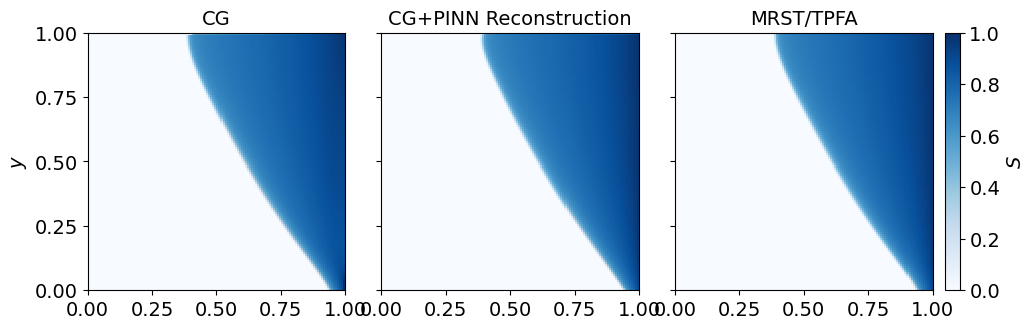

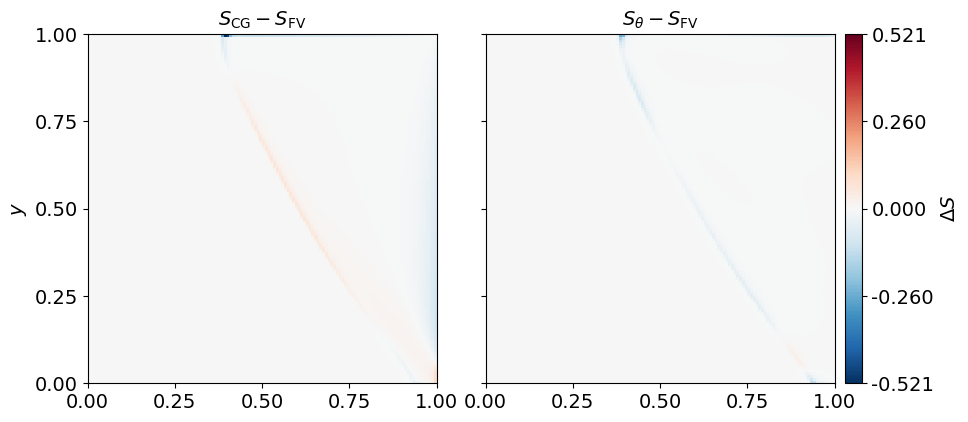

Selected case: PVI0.3, T=2.65658499e-02, PVI=0.300000
Saturation error relative to matched MRST/TPFA upwind transport:
  CG-MRST   mean|e|=3.531e-03 rmse=1.320e-02 max|e|=5.207e-01
  PINN-MRST mean|e|=1.197e-03 rmse=6.636e-03 max|e|=2.520e-01
Global water mass balance on the matrix-only rectangular grid (zero source):
  method        stored water      boundary net       source term        total net    balance error    error/in       nsteps       dt
  CG         2.987465e-01     2.987636e-01     0.000000e+00     2.987636e-01  -1.708354e-05 -5.714e-03%      940 2.8262e-05
  PINN       2.990664e-01     2.990664e-01     0.000000e+00     2.990664e-01   8.326673e-16  2.784e-13%      940 2.8262e-05
  MRST       3.000000e-01     3.000000e-01     0.000000e+00     3.000000e-01   1.665335e-15  5.551e-13%      940 2.8262e-05


In [17]:
# Saturation plots and final water balance for the selected matrix-only case.
def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

case_lookup = {key: (sw_key, matched_key, tfinal, pvi) for key, sw_key, matched_key, tfinal, pvi in transport_cases}
selected_sw_key, selected_matched_key, selected_T, selected_PVI = case_lookup[TRANSPORT_CASE_KEY]

x_edges = np.linspace(0.0, physdim[0], nx + 1)
y_edges = np.linspace(0.0, physdim[1], ny + 1)
plot_methods = ["CG", "PINN", "MRST"]
plot_titles = {"CG": "CG", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/TPFA"}

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4.5))
    pcm = None
    for ax, name in zip(axes, plot_methods):
        field = transport_results[TRANSPORT_CASE_KEY][name]["S"]
        pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
        ax.set_aspect("equal")
        ax.set_xlim(0.0, physdim[0])
        ax.set_ylim(0.0, physdim[1])
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title(plot_titles[name])
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.95, wspace=0.14)
    fig.canvas.draw()
    pos = axes[-1].get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S$")
    plt.show()

selected_reference_key = selected_matched_key if selected_matched_key in mrst else selected_sw_key
native_selected = _arr(selected_reference_key, float).reshape(-1)
transport_rect_error_method_names = np.asarray(["CG-MRST", "PINN-MRST"], dtype=object)
transport_rect_S_error = np.vstack([
    transport_results[TRANSPORT_CASE_KEY]["CG"]["S"] - native_selected,
    transport_results[TRANSPORT_CASE_KEY]["PINN"]["S"] - native_selected,
])

SAT_ERROR_COLOR_MODE = "linear"  # "symlog" reveals small signed errors; "linear" uses raw values.
SAT_ERROR_LINTHRESH = 2.0e-3
SAT_ERROR_CMAP = "RdBu_r"

_sat_err_lim = float(np.nanmax(np.abs(transport_rect_S_error)))
if not np.isfinite(_sat_err_lim) or _sat_err_lim <= 0.0:
    _sat_err_lim = 1.0e-12
_sat_err_ticks = np.array([-_sat_err_lim, -SAT_ERROR_LINTHRESH, 0.0, SAT_ERROR_LINTHRESH, _sat_err_lim], dtype=float)
if SAT_ERROR_COLOR_MODE == "symlog":
    from matplotlib.colors import SymLogNorm
    _sat_err_linthresh = min(float(SAT_ERROR_LINTHRESH), max(_sat_err_lim / 10.0, 1.0e-12))
    _sat_err_norm = SymLogNorm(linthresh=_sat_err_linthresh, linscale=0.45, vmin=-_sat_err_lim, vmax=_sat_err_lim, base=10.0)
    _sat_err_ticks = np.array([-_sat_err_lim, -_sat_err_linthresh, 0.0, _sat_err_linthresh, _sat_err_lim], dtype=float)
elif SAT_ERROR_COLOR_MODE == "linear":
    _sat_err_norm = None
    _sat_err_ticks = np.linspace(-_sat_err_lim, _sat_err_lim, 5)
else:
    raise ValueError("SAT_ERROR_COLOR_MODE must be 'symlog' or 'linear'.")

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    pcm = None
    for ax, err, title in zip(
        axes,
        transport_rect_S_error,
        [r"$S_{\mathrm{CG}}-S_{\mathrm{FV}}$", r"$S_{\theta}-S_{\mathrm{FV}}$"],
    ):
        if _sat_err_norm is None:
            pcm = ax.pcolormesh(
                x_edges, y_edges, cell_field_to_grid(err), cmap=SAT_ERROR_CMAP,
                vmin=-_sat_err_lim, vmax=_sat_err_lim, shading="flat",
            )
        else:
            pcm = ax.pcolormesh(
                x_edges, y_edges, cell_field_to_grid(err), cmap=SAT_ERROR_CMAP,
                norm=_sat_err_norm, shading="flat",
            )
        ax.set_aspect("equal")
        ax.set_xlim(0.0, physdim[0])
        ax.set_ylim(0.0, physdim[1])
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_title(title)
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    axes[1].tick_params(labelleft=False)
    fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.95, wspace=0.14)
    fig.canvas.draw()
    pos = axes[-1].get_position()
    cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.018, pos.height])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_ticks(_sat_err_ticks)
    cbar.set_ticklabels([f"{t:.3f}" for t in _sat_err_ticks])
    cbar.set_label(r"$\Delta S$")
    plt.show()

print(f"Selected case: {TRANSPORT_CASE_KEY}, T={selected_T:.8e}, PVI={selected_PVI:.6f}")
print("Saturation error relative to matched MRST/TPFA upwind transport:")
for name, err in zip(transport_rect_error_method_names, transport_rect_S_error):
    print(f"  {name:<9} mean|e|={np.mean(np.abs(err)):.3e} rmse={np.sqrt(np.mean(err**2)):.3e} max|e|={np.max(np.abs(err)):.3e}")

print("Global water mass balance on the matrix-only rectangular grid (zero source):")
print("  method        stored water      boundary net       source term        total net    balance error    error/in       nsteps       dt")
for name in transport_rect_method_names:
    meta = transport_rect_meta[str(name)]
    boundary_net = meta['water_in'] - meta['water_out']
    print(
        f"  {str(name):<6} {meta['water_mass']:16.6e} {boundary_net:16.6e} "
        f"{meta['water_source']:16.6e} {meta['water_net']:16.6e} "
        f"{meta['water_balance_error']:14.6e} {meta['water_balance_error_pct_in']:10.3e}% "
        f"{meta['nsteps']:8d} {meta['dt']:10.4e}"
    )


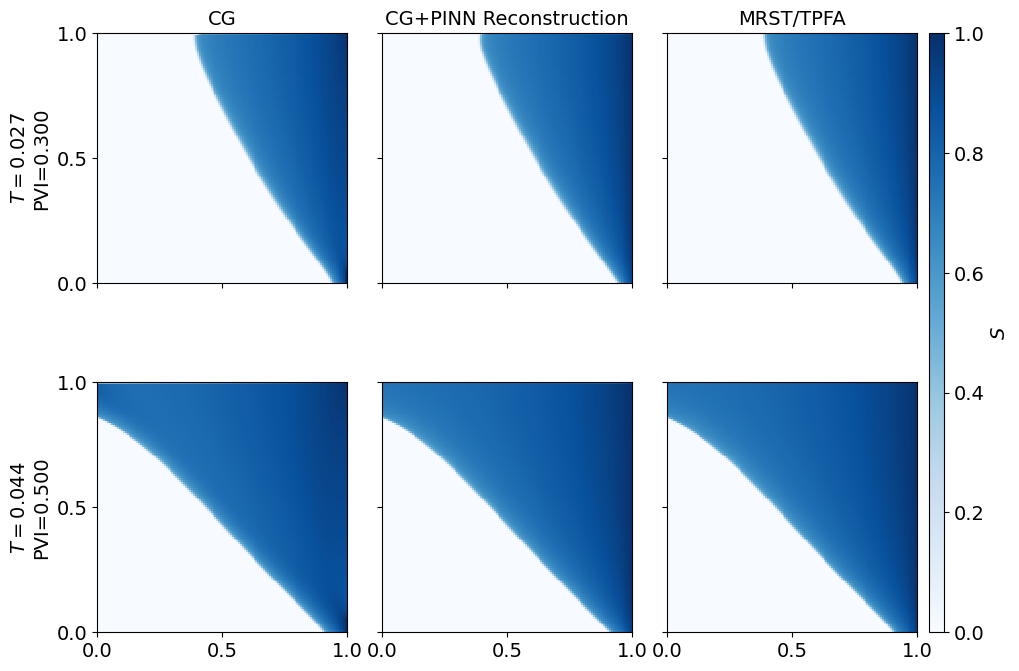

Time-step refinement check: shared tanh-transport dt versus shared dt/2
  PVI0.3  CG    RMSE=1.3874e-03, max|e|=3.3589e-02, nsteps_half=1880
  PVI0.3  PINN  RMSE=1.3872e-03, max|e|=3.1932e-02, nsteps_half=1880
  PVI0.3  MRST  RMSE=1.4014e-03, max|e|=3.3144e-02, nsteps_half=1880
  PVI0.5  CG    RMSE=7.5355e-04, max|e|=2.3770e-02, nsteps_half=3134
  PVI0.5  PINN  RMSE=7.5392e-04, max|e|=2.2446e-02, nsteps_half=3134
  PVI0.5  MRST  RMSE=7.5553e-04, max|e|=2.2215e-02, nsteps_half=3134


In [16]:
# Plot the exported time snapshots without rerunning transport.
row_cases = transport_cases[:2]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(len(row_cases), 3, figsize=(10, 3.8 * len(row_cases)), squeeze=False)
    pcm = None
    for ir, (key, sw_key, _, tfinal, pvi) in enumerate(row_cases):
        for ic, name in enumerate(plot_methods):
            ax = axes[ir, ic]
            field = transport_results[key][name]["S"]
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(0.0, physdim[0])
            ax.set_ylim(0.0, physdim[1])
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.grid(False)
            if ir == 0:
                ax.set_title(plot_titles[name])
            if ic == 0:
                ax.set_ylabel(rf"$T={tfinal:.3f}$" + "\n" + rf"PVI={pvi:.3f}")
            else:
                ax.tick_params(labelleft=False)
            if ir < len(row_cases) - 1:
                ax.tick_params(labelbottom=False)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.07, top=0.94, wspace=0.14, hspace=0.12)
    top = axes[0, -1].get_position()
    bottom = axes[-1, -1].get_position()
    cax = fig.add_axes([top.x1 + 0.012, bottom.y0, 0.015, top.y1 - bottom.y0])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S$")
    plt.show()

print("Time-step refinement check: shared tanh-transport dt versus shared dt/2")
for key, _, _, tfinal, _ in transport_cases:
    nsteps_ref = reference_nsteps[key]
    for name, Fout in transport_fluxes.items():
        S_dt = transport_results[key][name]["S"]
        S_half, meta_half = advance_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=2 * nsteps_ref)
        print(f"  {key:<7} {name:<5} RMSE={rmse(S_dt, S_half):.4e}, max|e|={maxabs(S_dt, S_half):.4e}, nsteps_half={meta_half['nsteps']}")


In [14]:
# Save compact diagnostics for paper tables/figures.
outdir = pathlib.Path("result_koppel_martin_tanh_d0p1_no_fracture_pinn_matrix_only")
outdir.mkdir(exist_ok=True)
if TORCH_AVAILABLE and q_net is not None:
    torch.save(
        {
            "q_net": q_net.state_dict(),
            "problem": "koppel_martin_tanh_d0p1_no_fracture",
            "kappa": "1 + 0.5*(Khi-1)*(1+tanh((x+y-1)/delta))",
            "Khi": float(KHI),
            "delta": float(TANH_DELTA),
            "source": "0",
            "CG_INTERFACE_FLUX_MODE": CG_INTERFACE_FLUX_MODE,
            "xy_center": [0.5 * physdim[0], 0.5 * physdim[1]],
            "xy_scale": float(max(physdim)),
        },
        outdir / "matrix_only_pinn_flux_reconstruction.pt",
    )
np.savez(
    outdir / "diagnostics.npz",
    xc_matrix=xc_matrix,
    p_matrix_cg=p_matrix_cg,
    p_matrix_mrst=p_matrix_mrst,
    p_matrix_diff_cg_mrst=p_matrix_diff_cg_mrst,
    kappa_cell_mrst=kappa_cell_mrst if kappa_cell_mrst is not None else kappa_numpy(xc_matrix),
    source_rate_cell=source_rate_cell,
    face_centroid=face_centroid,
    face_flux_mrst=face_flux_mrst,
    face_flux_cg=face_flux_cg_global,
    face_flux_pinn=face_flux_rec_global,
    R_zeta_cg=R_rotated_rect_cg,
    R_zeta_pinn=R_rotated_rect_rec,
    rotated_rect_centers=rotated_rect_centers,
    rotated_rect_areas=rotated_rect_areas,
    rotated_rect_source=rotated_rect_source,
    transport_method_names=transport_rect_method_names,
    transport_selected_case=TRANSPORT_CASE_KEY,
    transport_S=transport_rect_S,
    transport_water_mass=transport_rect_water_mass,
    transport_water_net=transport_rect_water_net,
    transport_water_balance_error=transport_rect_water_balance_error,
    transport_water_balance_error_pct_in=transport_rect_water_balance_error_pct_in,
    transport_dt=transport_rect_dt,
    transport_nsteps=transport_rect_nsteps,
    KHI=float(KHI),
    TANH_DELTA=float(TANH_DELTA),
    CG_INTERFACE_FLUX_MODE=CG_INTERFACE_FLUX_MODE,
)
print("saved:", outdir)


saved: result_koppel_martin_tanh_d0p1_no_fracture_pinn_matrix_only
